In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("sales_data_with_discounts.csv")
print(df)


           Date       Day  SKU City  Volume         BU  Brand       Model  \
0    01-04-2021  Thursday  M01    C      15    Mobiles  RealU       RU-10   
1    01-04-2021  Thursday  M02    C      10    Mobiles  RealU   RU-9 Plus   
2    01-04-2021  Thursday  M03    C       7    Mobiles   YouM       YM-99   
3    01-04-2021  Thursday  M04    C       6    Mobiles   YouM  YM-99 Plus   
4    01-04-2021  Thursday  M05    C       3    Mobiles   YouM      YM-98    
..          ...       ...  ...  ...     ...        ...    ...         ...   
445  15-04-2021  Thursday  L06    C       2  Lifestyle  Jeera   M-Casuals   
446  15-04-2021  Thursday  L07    C       6  Lifestyle   Viva   W-Western   
447  15-04-2021  Thursday  L08    C       2  Lifestyle   Viva    W-Lounge   
448  15-04-2021  Thursday  L09    C       3  Lifestyle  Jeera   M-Formals   
449  15-04-2021  Thursday  L10    C       1  Lifestyle  Jeera     M-Shoes   

     Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0 

Analyze the dataset
Identify Numerical Columns

In [4]:
print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns)

First 5 rows:
         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053

In [5]:
#Identify Categorical Columns
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


Calculate the mean, median, mode, and standard deviation.

In [6]:
#mean
mean_values = df[numerical_columns].mean()

print("Mean:")
print(mean_values)

#median
median_values = df[numerical_columns].median()

print("Median:")
print(median_values)

#mode
mode_values = df[numerical_columns].mode().iloc[0]

print("Mode:")
print(mode_values)

#standard deviation
std_values = df[numerical_columns].std()

print("Standard Deviation:")
print(std_values)

Mean:
Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64
Median:
Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64
Mode:
Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64
Standard Deviation:
Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


Create One Statistics Table

In [7]:
statistics = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

print(statistics)

                           Mean       Median          Mode  Standard Deviation
Volume                 5.066667     4.000000      3.000000            4.231602
Avg Price          10453.433333  1450.000000    400.000000        18079.904840
Total Sales Value  33812.835556  5700.000000  24300.000000        50535.074173
Discount Rate (%)     15.155242    16.577766      5.007822            4.220602
Discount Amount     3346.499424   988.933733     69.177942         4509.902963
Net Sales Value    30466.336131  4677.788059    326.974801        46358.656624


Interpretation
Mean represents the average value of each numerical variable.
Median represents the middle value of each numerical variable.
Mode represents the most frequently occurring value.
Standard deviation shows the amount of variation or spread in the data.
A large difference between the mean and median may indicate a skewed distribution or the presence of extreme values.
A high standard deviation indicates that the values are widely spread around the mean.

Plot histograms for each numerical column.

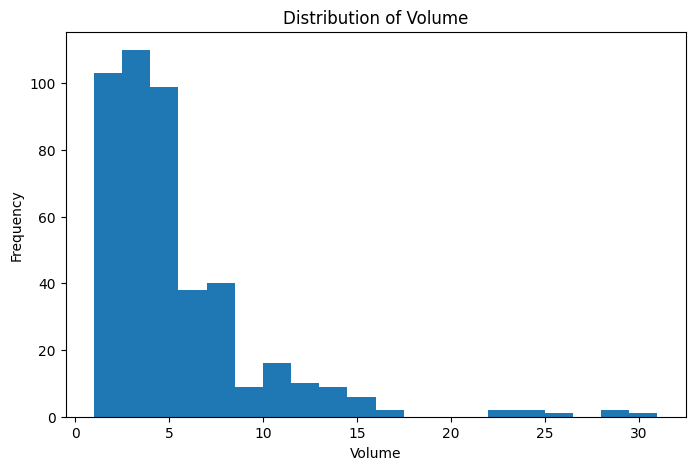

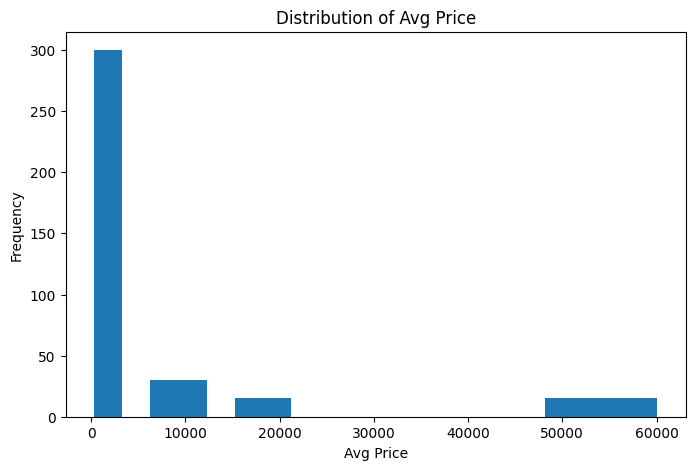

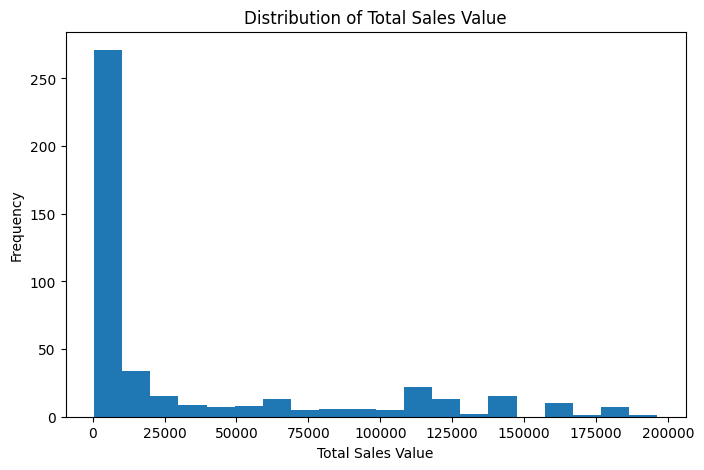

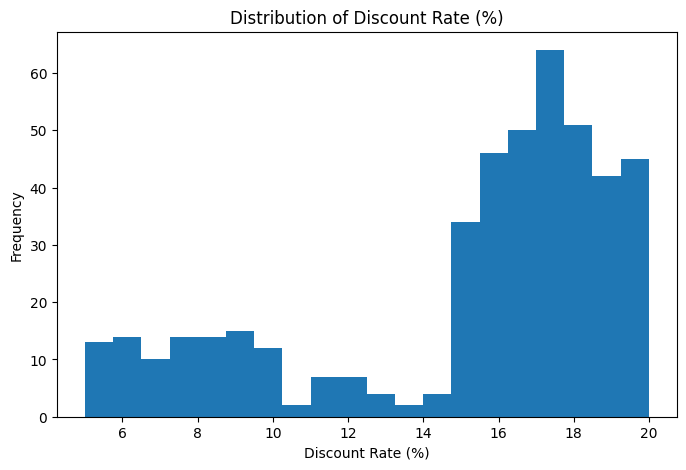

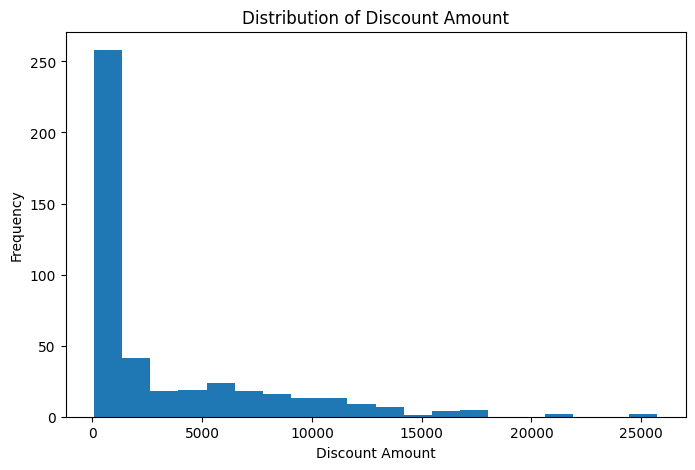

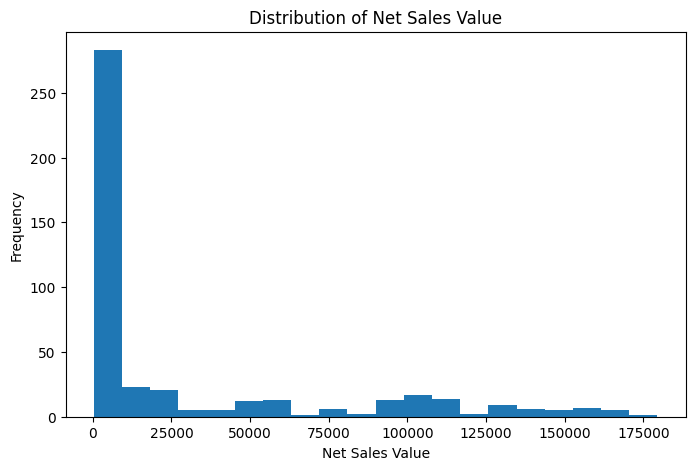

In [8]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

Histogram Analysis

The histograms show the distribution of the numerical variables in the sales dataset. The variables have different ranges and distributions. Some variables show concentration around particular values, while others are more widely distributed. Differences between the mean and median can indicate skewness. Extreme values at the lower or upper end of a distribution may indicate possible outliers.

Create boxplots for numerical variables to identify outliers and the interquartile range.

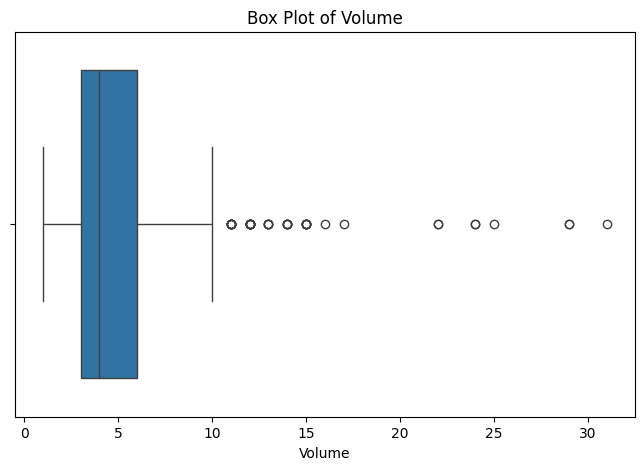

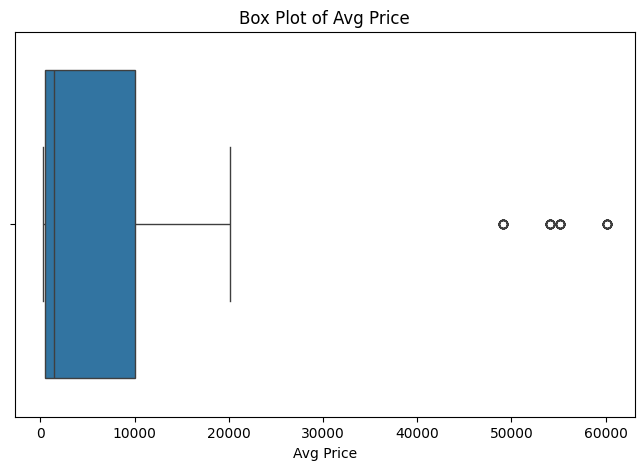

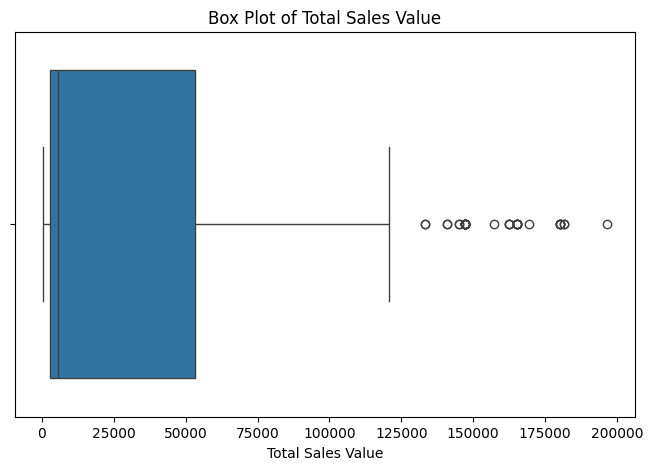

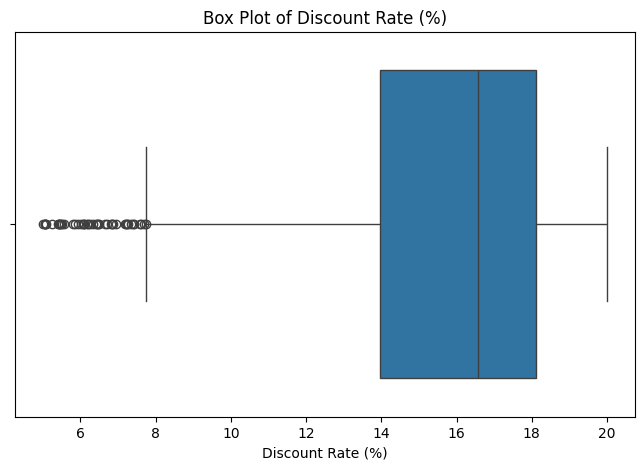

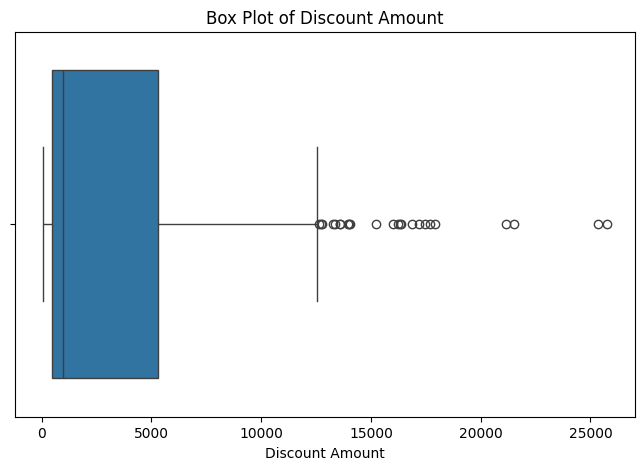

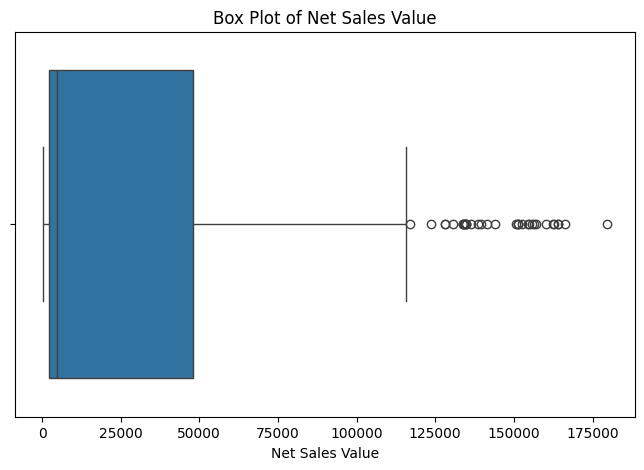

In [9]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

Box Plot Analysis

The box plots help identify the spread, median, interquartile range, and possible outliers in the numerical variables. Variables with longer whiskers or many points outside the whiskers have greater variation and may contain potential outliers. The position of the median inside the box also provides information about the distribution of the data.

Identify categorical columns in the dataset.

In [10]:
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


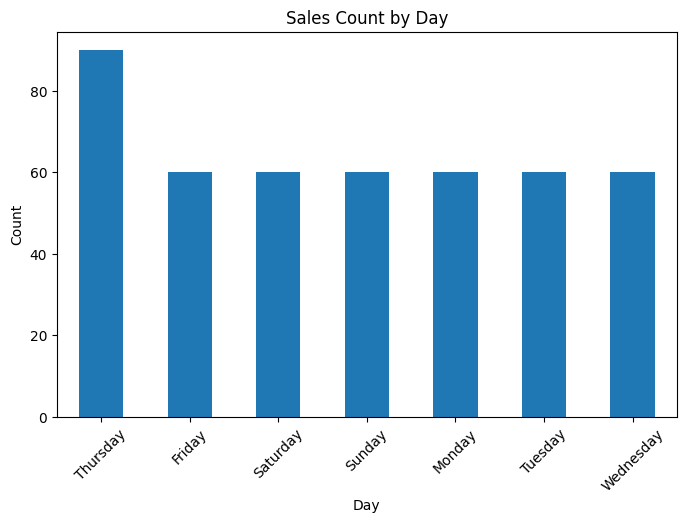

In [12]:
#Bar chart for day
plt.figure(figsize=(8, 5))

df['Day'].value_counts().plot(kind='bar')

plt.title("Sales Count by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

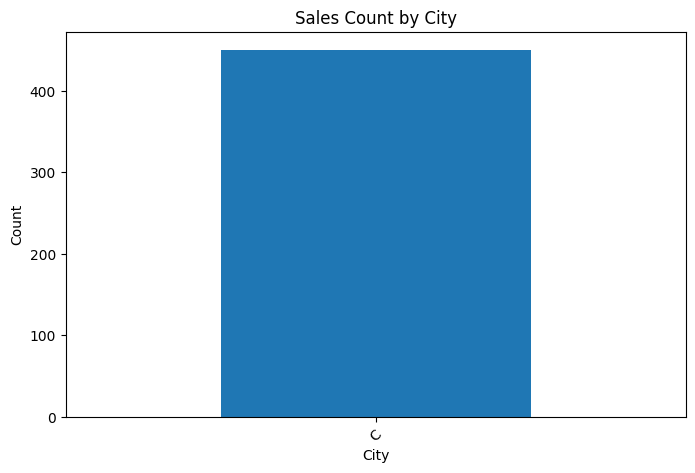

In [13]:
#Bar chart for city
plt.figure(figsize=(8, 5))

df['City'].value_counts().plot(kind='bar')

plt.title("Sales Count by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

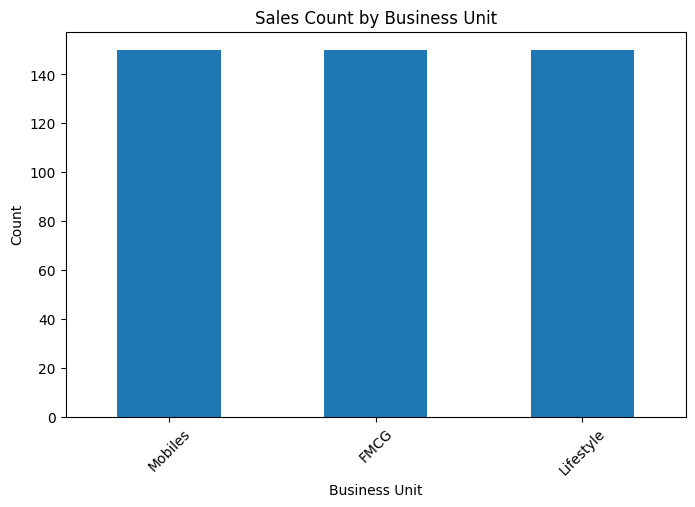

In [14]:
#Bar Chart for BU
plt.figure(figsize=(8, 5))

df['BU'].value_counts().plot(kind='bar')

plt.title("Sales Count by Business Unit")
plt.xlabel("Business Unit")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

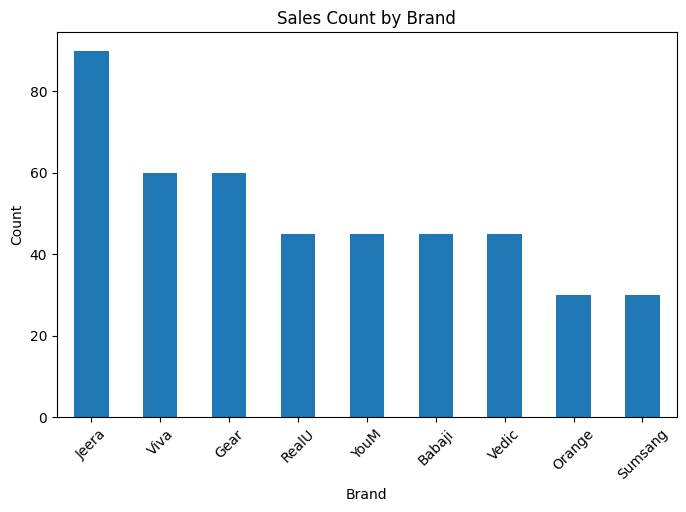

In [15]:
#Bar Chart for Brand
plt.figure(figsize=(8, 5))

df['Brand'].value_counts().plot(kind='bar')

plt.title("Sales Count by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Categorical Variable Analysis

The bar charts show the frequency of observations across different categories. The distribution of records is not necessarily equal across all categories. Some categories have higher frequencies, while others have lower frequencies. This helps identify which days, cities, business units, and brands have greater representation in the dataset.

In [17]:
#missing values
print("Missing values:")
print(df.isnull().sum())

#duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Missing values:
Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64
Number of duplicate rows: 0


#**Conclusion :**


The sales and discounts dataset was analyzed using descriptive statistics and data visualization techniques. Numerical variables were analyzed using mean, median, mode, and standard deviation to understand their central tendency and variability. Histograms were used to examine the distributions of numerical variables, while box plots helped identify the spread of the data and potential outliers. Bar charts were used to analyze the frequency of categorical variables such as day, city, business unit, and brand. Overall, the analysis provides a better understanding of the sales, discount, and net sales patterns in the dataset and prepares the data for further analysis.